| **BO1: Aide les entreprises à anticiper les métiers à recruter et adapter leurs plans RH et formation** | Classifier des métiers selon trajectoire 2024→2030(croissance / stable / déclin). | Classification | Random Forest, XGBoost, Logistic Regression |

# **KNN**

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                           precision_score, recall_score, f1_score, roc_auc_score)
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

In [19]:

# 1) Préparation des données pour KNN
df_knn =  pd.read_csv(r"C:\Users\meria\Downloads\mlProject\prepared_data.csv")

# Vérifier et supprimer les colonnes non numériques
non_numeric_cols = df_knn.select_dtypes(exclude=[np.number]).columns
print(f"Colonnes non numériques à supprimer: {list(non_numeric_cols)}")

# Supprimer toutes les colonnes non numériques sauf la target
df_knn_numeric = df_knn.select_dtypes(include=[np.number]).copy()

# Encoder la variable cible
le = LabelEncoder()
df_knn_numeric["Growth_Category_num"] = le.fit_transform(df_knn["Growth_Category"])

# Vérifier les données
print(f"Shape après nettoyage: {df_knn_numeric.shape}")
print(f"Colonnes numériques: {df_knn_numeric.columns.tolist()}")

# 2) Séparation features/target
y = df_knn_numeric["Growth_Category_num"]
X = df_knn_numeric.drop(columns=["Growth_Category_num"])

# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Colonnes non numériques à supprimer: ['Job_Title', 'Growth_Category']
Shape après nettoyage: (30000, 28)
Colonnes numériques: ['Median_Salary_USD', 'Experience_Required_Years', 'Remote_Work_Ratio_%', 'Automation_Risk_%', 'Gender_Diversity_%', 'Job_Growth_Rate_%', 'Job_Value_Index', 'Vulnerability_Index', 'Required_Education_num', 'AI_Impact_Level_num', 'Job_Status_num', 'Industry_education', 'Industry_entertainment', 'Industry_finance', 'Industry_healthcare', 'Industry_it', 'Industry_manufacturing', 'Industry_retail', 'Industry_transportation', 'Location_australia', 'Location_brazil', 'Location_canada', 'Location_china', 'Location_germany', 'Location_india', 'Location_uk', 'Location_usa', 'Growth_Category_num']


In [20]:
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (24000, 27), Test shape: (6000, 27)


In [21]:
KNN= KNeighborsClassifier(n_neighbors=5)
# entrainer
KNN.fit(X_train, y_train)
# calculer y_pred
y_pred = KNN.predict(X_test)
# affichage y_test[i], y_pred_knn[i]
print(np.array(y_test)) # y_test converti en np.ndarray pour l'affichage
print(y_pred)
print(KNN.score(X_test, y_test))

[1 1 0 ... 1 1 1]
[0 0 1 ... 1 1 1]
0.5058333333333334


✅ Précision KNN basique : 0.506

Rapport de classification KNN basique :
              precision    recall  f1-score   support

     decline       0.49      0.65      0.56      2680
 high_growth       0.54      0.47      0.50      2728
      stable       0.07      0.01      0.01       592

    accuracy                           0.51      6000
   macro avg       0.37      0.38      0.36      6000
weighted avg       0.47      0.51      0.48      6000



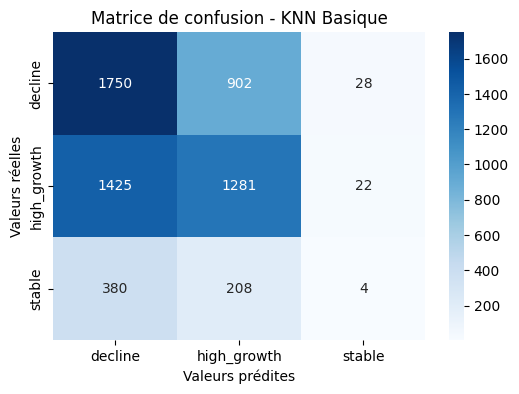

In [22]:
# Évaluation
acc_basic = accuracy_score(y_test, y_pred)
print(f"✅ Précision KNN basique : {acc_basic:.3f}")
print("\nRapport de classification KNN basique :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matrice de confusion
plt.figure(figsize=(6, 4))
cm_basic = confusion_matrix(y_test, y_pred)
sns.heatmap(cm_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion - KNN Basique")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.49      0.65      0.56      2680
           1       0.54      0.47      0.50      2728
           2       0.07      0.01      0.01       592

    accuracy                           0.51      6000
   macro avg       0.37      0.38      0.36      6000
weighted avg       0.47      0.51      0.48      6000



🔍 Optimisation des hyperparamètres...
✅ Meilleur KNN - Précision : 0.566
🔧 Meilleurs paramètres : {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}

Rapport de classification KNN optimisé :
              precision    recall  f1-score   support

     decline       0.54      0.71      0.61      2680
 high_growth       0.61      0.54      0.58      2728
      stable       0.03      0.00      0.00       592

    accuracy                           0.57      6000
   macro avg       0.39      0.42      0.40      6000
weighted avg       0.52      0.57      0.54      6000



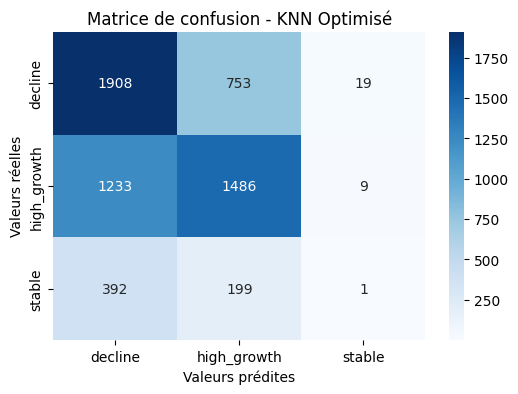


📊 COMPARAISON DES MODÈLES:
         Modèle  Précision                                         Paramètres
0   KNN Basique   0.505833                                                k=5
1  KNN Optimisé   0.565833  {'metric': 'manhattan', 'n_neighbors': 14, 'we...


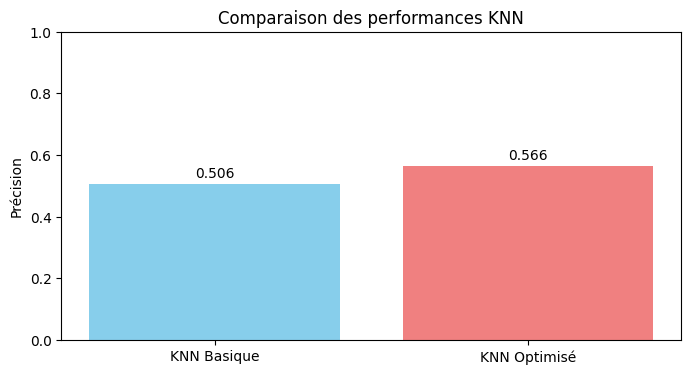

In [24]:
#  run time :6 minutes
print("🔍 Optimisation des hyperparamètres...")
# Recherche des meilleurs hyperparamètres
param_grid = {
    'n_neighbors': range(3, 15),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
knn_grid = GridSearchCV(
    KNeighborsClassifier(), 
    param_grid, 
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

# Meilleur modèle
best_knn = knn_grid.best_estimator_
y_pred_best = best_knn.predict(X_test)

# Évaluation du modèle optimisé
acc_best = accuracy_score(y_test, y_pred_best)
print(f"✅ Meilleur KNN - Précision : {acc_best:.3f}")
print(f"🔧 Meilleurs paramètres : {knn_grid.best_params_}")

print("\nRapport de classification KNN optimisé :")
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

# Matrice de confusion optimisée
plt.figure(figsize=(6, 4))
cm_best = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Matrice de confusion - KNN Optimisé")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()

# ===============================
# 📊 Visualisation des performances
# ===============================

# Comparaison des performances
models_comparison = pd.DataFrame({
    'Modèle': ['KNN Basique', 'KNN Optimisé'],
    'Précision': [acc_basic, acc_best],
    'Paramètres': ['k=5', str(knn_grid.best_params_)]
})

print("\n📊 COMPARAISON DES MODÈLES:")
print(models_comparison)

# Graphique de comparaison
plt.figure(figsize=(8, 4))
plt.bar(models_comparison['Modèle'], models_comparison['Précision'], color=['skyblue', 'lightcoral'])
plt.title('Comparaison des performances KNN')
plt.ylabel('Précision')
plt.ylim(0, 1)
for i, v in enumerate(models_comparison['Précision']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.show()

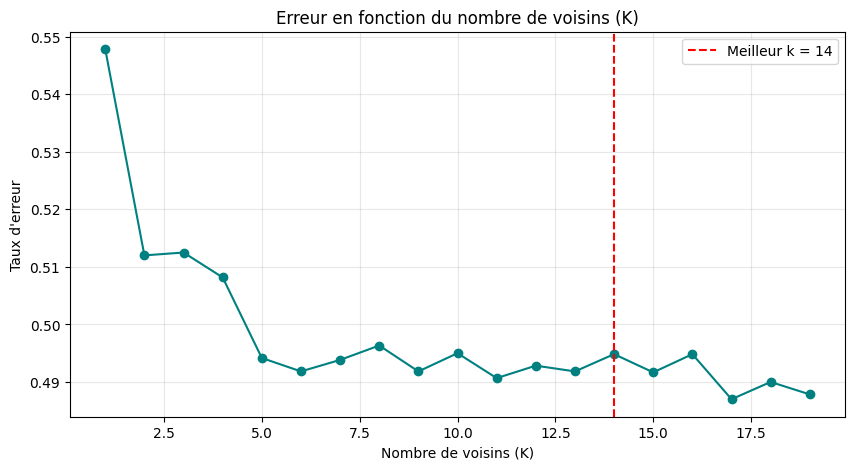

In [25]:
# 🔮 Analyse de l'impact du nombre de voisins
errors = []
neighbors_range = range(1, 20)

for k in neighbors_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred_k = model.predict(X_test)
    errors.append(1 - accuracy_score(y_test, pred_k))

plt.figure(figsize=(10, 5))
plt.plot(neighbors_range, errors, marker='o', linestyle='-', color='teal')
plt.axvline(x=knn_grid.best_params_['n_neighbors'], color='red', linestyle='--', 
            label=f'Meilleur k = {knn_grid.best_params_["n_neighbors"]}')
plt.title("Erreur en fonction du nombre de voisins (K)")
plt.xlabel("Nombre de voisins (K)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Modèle Arbre de Décision 


 ARBRE DE DÉCISION
✔️ Précision Arbre : 1.000

📌 Rapport Arbre de Décision :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2680
           1       1.00      1.00      1.00      2728
           2       1.00      1.00      1.00       592

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



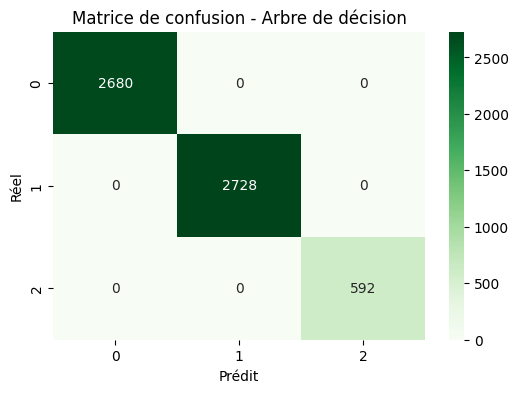

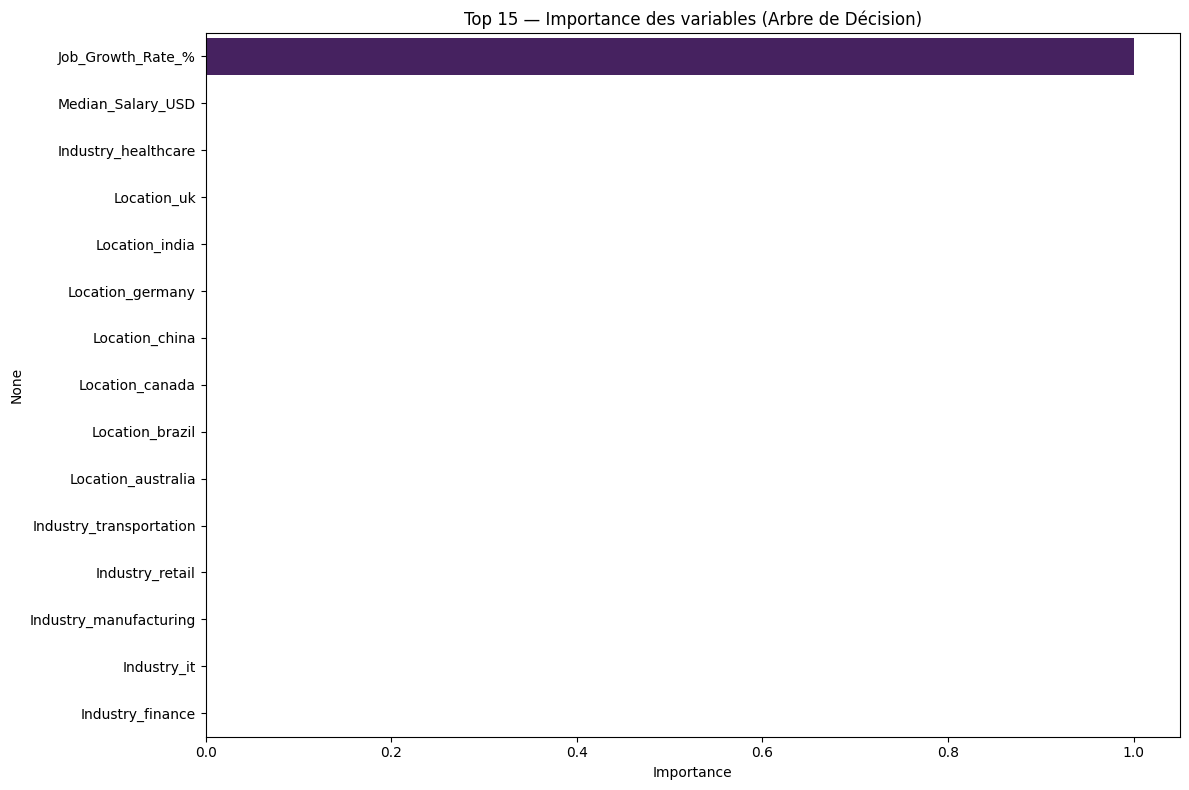


📊 TOP 10 variables importantes :
1. Job_Growth_Rate_% — 1.0000
2. Median_Salary_USD — 0.0000
3. Industry_healthcare — 0.0000
4. Location_uk — 0.0000
5. Location_india — 0.0000
6. Location_germany — 0.0000
7. Location_china — 0.0000
8. Location_canada — 0.0000
9. Location_brazil — 0.0000
10. Location_australia — 0.0000


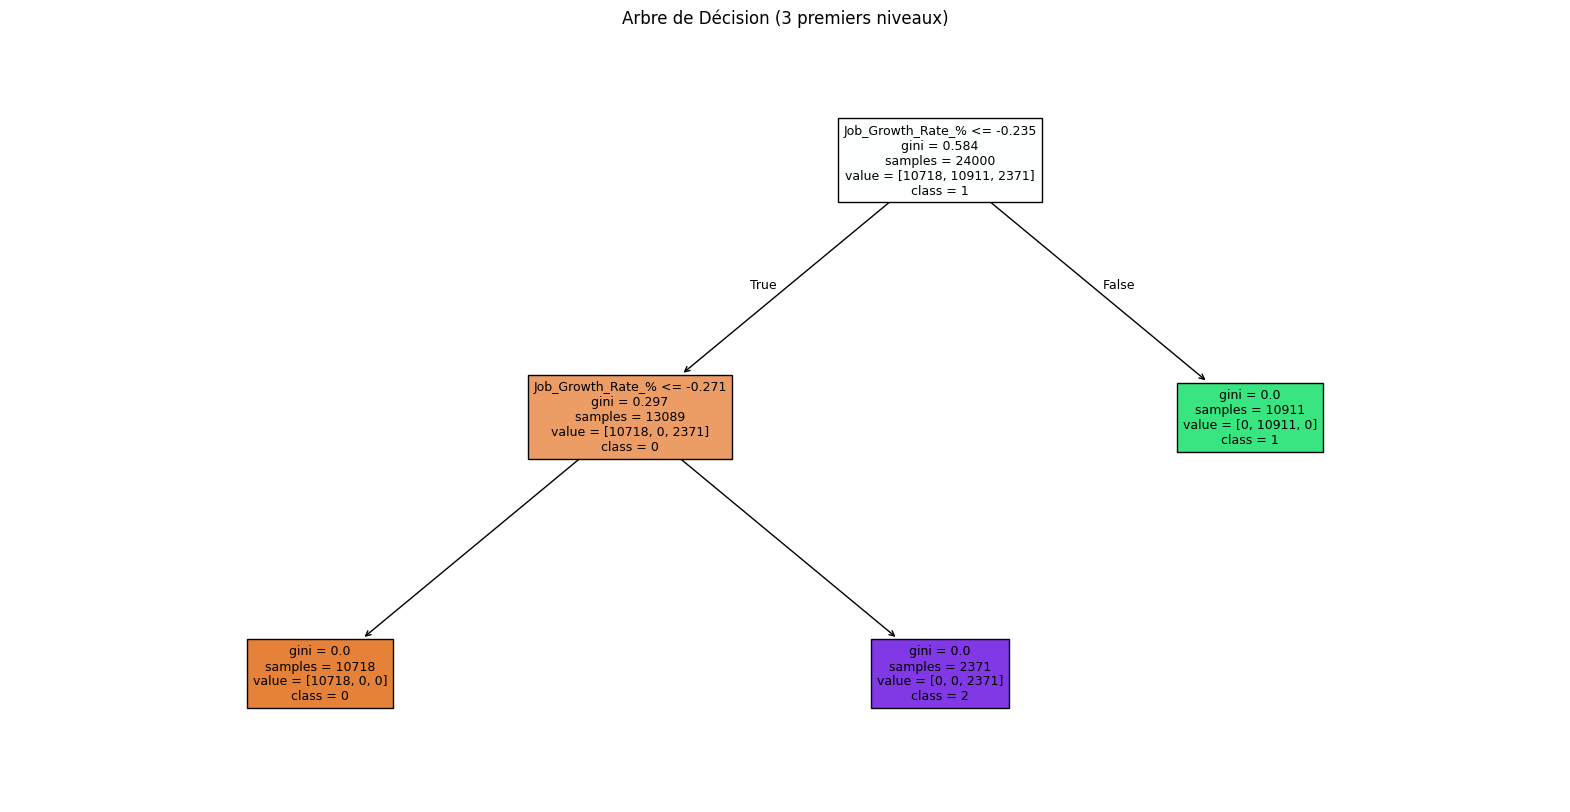

In [38]:
# 🌳 ARBRE DE DÉCISION — VERSION FIXÉE
from sklearn.tree import DecisionTreeClassifier, plot_tree
print(" ARBRE DE DÉCISION")


# 1) Entraînement (max_depth réduit pour stabilité)
tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,          # ← évite l’overfitting massif
)
tree.fit(X_train, y_train)

# 2) Prédiction
y_pred_tree = tree.predict(X_test)

# 3) Évaluation
acc_tree = accuracy_score(y_test, y_pred_tree)
print(f"✔️ Précision Arbre : {acc_tree:.3f}")

print("\n📌 Rapport Arbre de Décision :")
# CORRECTION : Conversion des classes en strings
target_names = [str(c) for c in le.classes_]
print(classification_report(y_test, y_pred_tree, target_names=target_names))


# 4) Matrice de confusion
plt.figure(figsize=(6, 4))
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Greens",
            xticklabels=target_names,  # CORRECTION ici aussi
            yticklabels=target_names)  # CORRECTION ici aussi
plt.title("Matrice de confusion - Arbre de décision")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# 5) Importance des variables
feature_importance = pd.Series(tree.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importance.head(15).values,
            y=feature_importance.head(15).index,
            palette="viridis")
plt.title("Top 15 — Importance des variables (Arbre de Décision)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("\n📊 TOP 10 variables importantes :")
for i, (f, imp) in enumerate(feature_importance.head(10).items(), 1):
    print(f"{i}. {f} — {imp:.4f}")

# 6) Visualisation de l'arbre (simplifiée)
plt.figure(figsize=(20, 10))
plot_tree(tree,
          filled=True,
          feature_names=X_train.columns,
          class_names=target_names,  # CORRECTION ici aussi
          fontsize=9)
plt.title("Arbre de Décision (3 premiers niveaux)")
plt.show()

#  COMPARAISON FINALE DES MODÈLES

# Régression Linéaire


✅ Précision Régression Logistique : 0.951

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      1.00      0.97      2680
           1       0.96      1.00      0.98      2728
           2       1.00      0.50      0.67       592

    accuracy                           0.95      6000
   macro avg       0.97      0.83      0.87      6000
weighted avg       0.95      0.95      0.94      6000



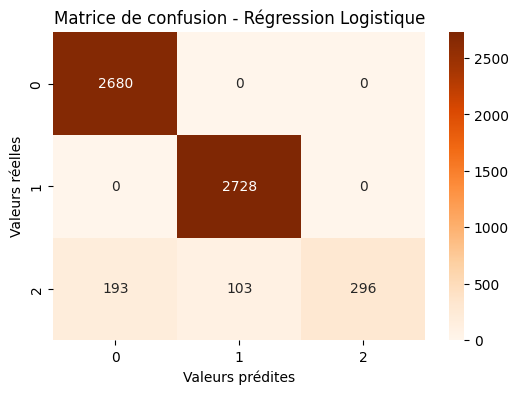

In [37]:
from sklearn.linear_model import LogisticRegression

# On réutilise exactement les mêmes labels
y_train_encoded = y_train.values
y_test_encoded = y_test.values

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train_encoded)

y_pred_log = log_reg.predict(X_test)

acc_log = accuracy_score(y_test_encoded, y_pred_log)
print(f"✅ Précision Régression Logistique : {acc_log:.3f}")

print("\nRapport de classification :")
print(classification_report(y_test_encoded, y_pred_log, target_names=target_names))

# Matrice de confusion
plt.figure(figsize=(6, 4))
cm_log = confusion_matrix(y_test_encoded, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Matrice de confusion - Régression Logistique")
plt.xlabel("Valeurs prédites")
plt.ylabel("Valeurs réelles")
plt.show()
